# TP MODELISATION DU CHURN

# Sommaire

1. [Import de la table préparée et Séparation Train / Test](#sect1)
2. [Standardisation des variables](#sect2)
3. [Modélisation](#sectmodel)
  - [Régression pénalisée](#sect41)
  - [Random Forest](#sect43)
  - [GBM (Gradient Boosting Machine)](#sect44)

In [18]:
import pandas as pd
import os
import numpy as np
import pickle
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,f1_score,roc_auc_score,roc_curve,auc

import matplotlib.pyplot as plt

# 1 Chargement des données préparées <a name="sect1" ></a>

In [19]:
repertoire = "../data"
os.chdir(repertoire)
file=open("churn_prepared.pydata","rb")
data=pickle.load(file)
file.close()

In [20]:
data.shape

(3333, 21)

In [21]:
data.describe()


,churnMoy_state,Account Length,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,0.145772,101.064806,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856
std,0.061771,39.822106,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491
min,0.035714,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,0.095238,74.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000
50%,0.130435,101.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000
75%,0.193548,127.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000
max,0.289474,243.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [22]:
data.dtypes

churnMoy_state    float64
Account Length      int64
Int'l Plan           bool
VMail Plan           bool
VMail Message       int64
Day Mins          float64
Day Calls           int64
Day Charge        float64
Eve Mins          float64
Eve Calls           int64
Eve Charge        float64
Night Mins        float64
Night Calls         int64
Night Charge      float64
Intl Mins         float64
Intl Calls          int64
Intl Charge       float64
CustServ Calls      int64
Churn?             object
Area Code_415        bool
Area Code_510        bool
dtype: object

In [23]:
X = data.drop('Churn?',axis=1)
y =data['Churn?'].astype(int)

In [24]:
y.value_counts(normalize=True)

Churn?
0    0.855086
1    0.144914
Name: proportion, dtype: float64

In [25]:
# split Apprentissage Test
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(X,y, stratify=y, test_size=0.3,random_state=42)

In [26]:
X_train.shape, X_test.shape

((2333, 20), (1000, 20))

In [27]:
y_train.sum(), y_test.sum()

(np.int64(338), np.int64(145))

In [28]:
y_train.mean(), y_test.mean()

(np.float64(0.14487783969138449), np.float64(0.145))

# 2. Standardisation des variables <a name="sect2" ></a>

## Attention ici, on fit le scaler sur les données de train et on applique ce dernier à la fois sur les données de train et de test.
Il ne faut pas faut fit le scaler sur les données de test car cela serait considérer comme du leakage. ("data leakage" = utiliser,considérer, "regarder" les données de test pendant l'entrainement..)

In [29]:
from sklearn.preprocessing import StandardScaler
norm = StandardScaler().fit(X_train) 
X_train = pd.DataFrame(norm.transform(X_train), columns=X.columns)
X_test = pd.DataFrame(norm.transform(X_test), columns=X.columns)

In [30]:
X_train.describe()

,churnMoy_state,Account Length,Int'l Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Area Code_415,Area Code_510
count,2.333000e+03,2.333000e+03,2.333000e+03,2.333000e+03,2.333000e+03,2.333000e+03,2.333000e+03,2.333000e+03,2.333000e+03,2.333000e+03,2.333000e+03,2.333000e+03,2.333000e+03,2.333000e+03,2.333000e+03,2.333000e+03,2.333000e+03,2.333000e+03,2.333000e+03,2.333000e+03
mean,-1.903511e-16,-1.614178e-16,3.350180e-17,3.350180e-17,8.527731e-17,-2.664916e-16,-2.215687e-16,-5.710534e-16,1.964424e-16,3.220741e-16,-3.136987e-16,-9.593697e-17,-7.614046e-18,7.279028e-16,-2.010108e-16,-9.136855e-17,3.959304e-16,-5.482113e-17,4.187725e-18,-2.131933e-17
std,1.000214e+00,1.000214e+00,1.000214e+00,1.000214e+00,1.000214e+00,1.000214e+00,1.000214e+00,1.000214e+00,1.000214e+00,1.000214e+00,1.000214e+00,1.000214e+00,1.000214e+00,1.000214e+00,1.000214e+00,1.000214e+00,1.000214e+00,1.000214e+00,1.000214e+00,1.000214e+00
min,-1.784019e+00,-2.487259e+00,-3.186077e-01,-6.287567e-01,-6.014372e-01,-3.331687e+00,-5.004624e+00,-3.331755e+00,-3.942555e+00,-4.997841e+00,-3.942646e+00,-3.557234e+00,-3.436090e+00,-3.558946e+00,-3.601369e+00,-1.856517e+00,-3.601979e+00,-1.202826e+00,-1.006450e+00,-5.679457e-01
25%,-8.153774e-01,-6.634062e-01,-3.186077e-01,-6.287567e-01,-6.014372e-01,-6.710391e-01,-6.624940e-01,-6.705548e-01,-6.949818e-01,-6.613366e-01,-6.953804e-01,-6.760070e-01,-6.688108e-01,-6.742155e-01,-6.451014e-01,-6.183081e-01,-6.431349e-01,-4.329515e-01,-1.006450e+00,-5.679457e-01
50%,-2.426155e-01,-1.381472e-02,-3.186077e-01,-6.287567e-01,-6.014372e-01,-7.267824e-03,3.623950e-02,-7.435909e-03,1.952346e-02,-1.335321e-02,1.855747e-02,-7.867457e-03,-2.613915e-03,-9.880450e-03,2.357809e-02,-2.055720e-01,2.162742e-02,-4.329515e-01,9.935910e-01,-5.679457e-01
75%,7.844434e-01,6.607610e-01,-3.186077e-01,1.590440e+00,8.570659e-01,6.713363e-01,6.850635e-01,6.709521e-01,6.576843e-01,6.844750e-01,6.587986e-01,6.662914e-01,6.635829e-01,6.678305e-01,6.570640e-01,6.199004e-01,6.603206e-01,3.369234e-01,9.935910e-01,-5.679457e-01
max,2.345453e+00,3.558938e+00,3.138656e+00,1.590440e+00,3.117746e+00,3.172530e+00,3.230450e+00,3.172917e+00,3.177049e+00,3.475788e+00,3.176005e+00,3.902655e+00,3.840829e+00,3.900333e+00,3.437363e+00,5.572734e+00,3.436681e+00,5.726047e+00,9.935910e-01,1.760732e+00


In [31]:
X_test.describe()

,churnMoy_state,Account Length,Int'l Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Area Code_415,Area Code_510
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.023222,0.042625,0.054777,-0.049546,-0.036048,0.005136,0.026906,0.005136,-0.027554,-0.025515,-0.027542,0.025407,0.009685,0.025508,0.005031,-0.025619,0.005100,0.001258,-0.044430,0.063126
std,1.017102,0.982330,1.073604,0.975114,0.993613,1.032593,1.005203,1.032595,0.975330,0.976362,0.975363,1.048096,1.009313,1.048094,0.940531,1.051659,0.940386,1.041961,0.999798,1.035559
min,-1.784019,-2.487259,-0.318608,-0.628757,-0.601437,-3.331687,-5.004624,-3.331755,-3.000974,-2.854511,-3.000709,-3.145916,-3.179860,-3.144294,-3.601369,-1.856517,-3.601979,-1.202826,-1.006450,-0.567946
25%,-0.885824,-0.638422,-0.318608,-0.628757,-0.601437,-0.652498,-0.612584,-0.652832,-0.669534,-0.661337,-0.670047,-0.647415,-0.668811,-0.648578,-0.574714,-0.618308,-0.577962,-0.432951,-1.006450,-0.567946
50%,-0.120628,0.011170,-0.318608,-0.628757,-0.601437,0.012200,0.036240,0.012196,-0.033330,-0.013353,-0.034412,0.060351,-0.002614,0.061458,0.058772,-0.205572,0.060731,-0.432951,-1.006450,-0.567946
75%,0.810050,0.685745,-0.318608,1.590440,0.565365,0.720470,0.685063,0.720850,0.679707,0.634630,0.680102,0.793699,0.714829,0.793787,0.657064,0.619900,0.660321,0.336923,0.993591,1.760732
max,2.345453,3.084237,3.138656,1.590440,3.044821,3.098366,3.130631,3.098752,3.139856,3.176719,3.139157,3.639814,3.277124,3.641733,2.733490,6.398207,2.732815,5.726047,0.993591,1.760732


# 3. Modélisation <a name="sectmodel" ></a>

In [32]:
# Import de la fonction de lift à utiliser
os.chdir('../modules/')
from fonctions_metrics import lift

## 3.1 PARAMETRER LE MODELE REG PENALISEE <a name="sect41" ></a>
Choisir ridge (L2) ou lasso (L1) ou elasticnet, avec la classe LogisticRegression
Définir une grille d'hyper param pour C
et utliser GridSearchCV pour la balayer

Détails sur les paramètres de la GridSearchCV :
- cv=4 : le jeu d’entraînement est divisé en 4 parties (validation croisée). Chaque combinaison d’hyperparamètres est évaluée sur ces 4 folds.
- n_jobs=-1 : utilise tous les cœurs disponibles du processeur pour paralléliser les calculs, ce qui accélère fortement la recherche.
- refit=True : après la recherche, un nouvel estimateur est automatiquement réentraîné sur l’ensemble du jeu d’entraînement avec les meilleurs hyperparamètres trouvés. Ainsi, l’objet modeleLassoCV est directement exploitable (prédictions, score, etc.).
- scoring='roc_auc' : la métrique utilisée pour comparer les modèles est l’aire sous la courbe ROC (ROC AUC), adaptée aux problèmes de classification binaire déséquilibrée.


In [33]:
param = [{"C":[0.001,0.005,0.01,0.025,0.05,0.075,0.1]}]
# Instancie le modele LASSO : construction classe
lr=LogisticRegression(penalty='l1',solver='liblinear', class_weight="balanced")
# Grid Search : on indique le modele et la grille de param
modeleLassoCV = GridSearchCV (lr,param,cv = 4,n_jobs=-1,scoring='roc_auc', refit=True)


modeleLassoCV = modeleLassoCV.fit(X_train,y_train)
print(modeleLassoCV.best_params_)
print(modeleLassoCV.best_score_)

{'C': 0.05}
0.825328986412635


In [34]:
modeleLassoCV.best_params_['C']

0.05

In [35]:
pd.DataFrame(modeleLassoCV.cv_results_).sort_values(['rank_test_score'])

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,mean_test_score,std_test_score,rank_test_score
4,0.168359,0.077810,0.014528,0.003158,0.050,{'C': 0.05},0.808157,0.821548,0.834001,0.837609,0.825329,0.011567,1
5,0.099600,0.120512,0.014395,0.003204,0.075,{'C': 0.075},0.808417,0.822502,0.832451,0.836546,0.824979,0.010840,2
6,0.192074,0.251752,0.007765,0.001591,0.100,{'C': 0.1},0.808818,0.822955,0.831854,0.835696,0.824831,0.010336,3
3,0.199357,0.126991,0.017242,0.009100,0.025,{'C': 0.025},0.805305,0.816848,0.835791,0.838129,0.824018,0.013595,4
2,0.020038,0.006821,0.011820,0.003871,0.010,{'C': 0.01},0.781351,0.798764,0.829826,0.818190,0.807033,0.018520,5
1,0.016253,0.006566,0.009863,0.004559,0.005,{'C': 0.005},0.779925,0.768656,0.816383,0.741094,0.776514,0.027007,6
0,0.019061,0.007930,0.016762,0.008313,0.001,{'C': 0.001},0.500000,0.500000,0.500000,0.500000,0.500000,0.000000,7


In [36]:
# Visualisation des coefficients estimées pour chaque variable
coef=list(modeleLassoCV.best_estimator_.coef_[0])
coef_df = pd.DataFrame({'Coefficients': list(coef)}, list(X_train.columns.values))
coef_df.sort_values(['Coefficients'], ascending=False)

,Coefficients
CustServ Calls,0.668387
Int'l Plan,0.606546
Day Charge,0.462186
churnMoy_state,0.310272
Eve Charge,0.250409
Intl Charge,0.135520
Day Mins,0.083446
Night Charge,0.058961
Eve Calls,0.036906
Account Length,0.027713


In [37]:
# combien d'élemnts non nuls ?
feature_0= [i for i in coef if i==0] #print(feature_0)
print(len(feature_0))
# PLus on baisse C, plus de colonnes s'annulent (0)

4


### Analyser les résultats et les performances 

In [38]:
# Prediction des probabilités de 1 avec 
# Colonne 1 signifie la seconde modalité du vecteur soit la proba Churn=1
probas_test = modeleLassoCV.predict_proba(X_test)[:,1]
probas_train = modeleLassoCV.predict_proba(X_train)[:,1]

In [39]:
# score: accuracy taux de bien classé global au cutoff de 0.5
print(modeleLassoCV.score(X_test, y_test))
print(modeleLassoCV.score(X_train,y_train))

0.8229562411776568
0.8317376280939034


In [40]:
#AUC
print(roc_auc_score(y_train,probas_train))
print(roc_auc_score(y_test,probas_test))

0.8317376280939034
0.8229562411776568


In [41]:
print(lift(probas_train,X_train,y_train))
print(lift(probas_test,X_test,y_test))

# Le lift à 10% : je prend les 10% plus fortes proba de churn (individus les plus risqués),
# taux de churn / taux de churn moyen 

lift at 10 percent : 3.58
3.58
lift at 10 percent : 3.86
3.86


In [42]:
#compute lift at 5%
print(lift(probas_train,X_train,y_train,p=5))
print(lift(probas_test,X_test,y_test,p=5))

lift at 5 percent : 3.91
3.91
lift at 5 percent : 4.28
4.28


In [43]:
# ENR LES RESULTATS DANS UN DICTIONNAIRE POUR POUVOIR COMPARER
model='Score Lasso'
# métriques (liste de dictionnaires)
metriques = [{'model':model,'AUC_test':round(roc_auc_score(y_test,probas_test),3),'lift at 5':lift(probas_test,X_test,y_test,p=5),'lift at 10':lift(probas_test,X_test,y_test,p=10)}]
metriques

lift at 5 percent : 4.28
lift at 10 percent : 3.86


[{'model': 'Score Lasso',
  'AUC_test': 0.823,
  'lift at 5': np.float64(4.28),
  'lift at 10': np.float64(3.86)}]

In [44]:
# mat de confusion à un cutoff donné
target_names = ['Fidèles','Churners']

# métriques au cutoff donné
print(classification_report(y_train,modeleLassoCV.predict(X_train), target_names=target_names))
# métriques au cutoff par défaut
print(classification_report(y_test,modeleLassoCV.predict(X_test), target_names=target_names))



              precision    recall  f1-score   support

     Fidèles       0.96      0.76      0.85      1995
    Churners       0.36      0.79      0.50       338

    accuracy                           0.77      2333
   macro avg       0.66      0.78      0.67      2333
weighted avg       0.87      0.77      0.80      2333

              precision    recall  f1-score   support

     Fidèles       0.95      0.76      0.84       855
    Churners       0.35      0.77      0.48       145

    accuracy                           0.76      1000
   macro avg       0.65      0.76      0.66      1000
weighted avg       0.86      0.76      0.79      1000



In [45]:
from fonctions_metrics import CAP_table, auc_et_roc
CAP_table(pd.Series(probas_test, index= y_test.index),y_test, stepsize=5,n=10)

,Population,Positifs parmi la population,% positifs,Population cumulée,Positifs cumulés,% Positifs cumulés,% positifs cumulés sur le total des positifs,Lift
5,50,31,62.0,50,31,62.00,21.38,4.28
10,50,25,50.0,100,56,56.00,38.62,3.86
15,50,14,28.0,150,70,46.67,48.28,3.22
20,50,13,26.0,200,83,41.50,57.24,2.86
25,50,13,26.0,250,96,38.40,66.21,2.65
30,50,12,24.0,300,108,36.00,74.48,2.48
35,50,5,10.0,350,113,32.29,77.93,2.23
40,50,6,12.0,400,119,29.75,82.07,2.05
45,50,3,6.0,450,122,27.11,84.14,1.87
50,50,2,4.0,500,124,24.80,85.52,1.71


auc= 0.8317376280939034


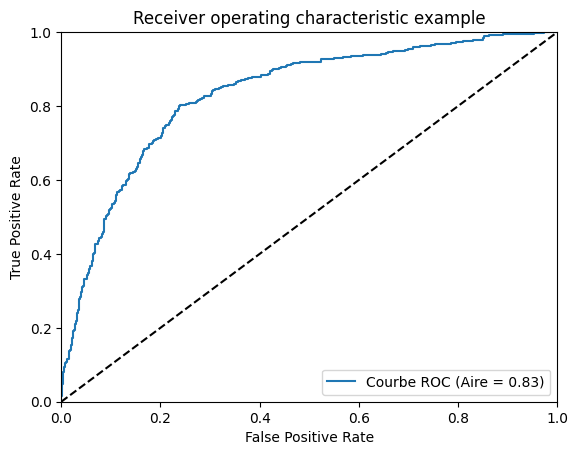

In [46]:
auc_et_roc(y_train, probas_train)

auc= 0.8229562411776568


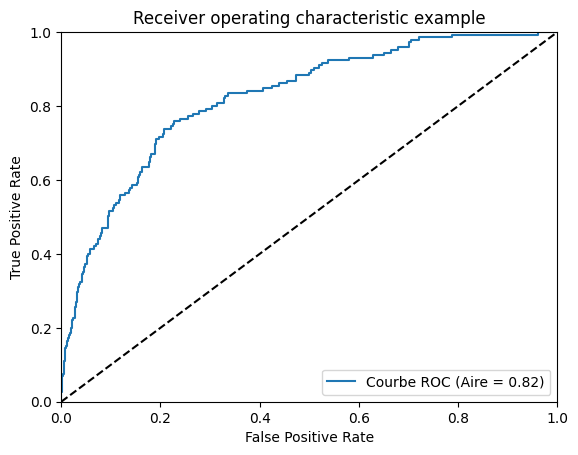

In [47]:
auc_et_roc(y_test, probas_test)

#### Sauvegarde du modèle en pickle

In [48]:
with open("../data/my_churn_model.pkl", "wb") as file:
    pickle.dump(modeleLassoCV, file)

In [49]:
# Test de réapplication
with open("../data/my_churn_model.pkl", "rb") as file:
    test_reapp_model = pickle.load(file)

In [50]:
test_reapp_model.predict_proba(X_test.head(5))

array([[0.60497236, 0.39502764],
       [0.15500871, 0.84499129],
       [0.76651238, 0.23348762],
       [0.37885812, 0.62114188],
       [0.47945675, 0.52054325]])

## 3.2 PARAMETRER LE MODELE RANDOMFOREST <a name="sect43" ></a>
Tester un modle light peu profond et un modele complexe

In [51]:
# exemple randomforest avec des rbres peu profonds
rf_light = RandomForestClassifier(                                                                       
                                       n_jobs = -1, # coeurs
                                       random_state = 42,
                                       class_weight = "balanced"
                                     )    

param = [{"n_estimators":[100,200,300], "max_depth":[3,4,5],"min_samples_split":[0.05,0.1]}]

# Grid Search : on indique le modele et la grille de param
modelerfCV = GridSearchCV (rf_light,param,cv = 4,n_jobs=-1,scoring='roc_auc', refit=True)
modelerfCV.fit(X_train,y_train)
print(modelerfCV.best_params_)
print(modelerfCV.best_score_)

{'max_depth': 5, 'min_samples_split': 0.05, 'n_estimators': 300}
0.8989429679445963


In [52]:
pd.DataFrame(modelerfCV.cv_results_).sort_values(['rank_test_score'])

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_split,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,mean_test_score,std_test_score,rank_test_score
14,2.459411,0.250503,0.176117,0.038073,5,0.05,300,"{'max_depth': 5, 'min_samples_split': 0.05, 'n...",0.877543,0.899943,0.913136,0.905150,0.898943,0.013218,1
13,1.608694,0.247758,0.116482,0.032229,5,0.05,200,"{'max_depth': 5, 'min_samples_split': 0.05, 'n...",0.876600,0.899776,0.908841,0.906922,0.898035,0.012828,2
12,0.871646,0.045150,0.087913,0.016880,5,0.05,100,"{'max_depth': 5, 'min_samples_split': 0.05, 'n...",0.878038,0.897247,0.908102,0.907489,0.897719,0.012153,3
8,2.291195,0.251374,0.197054,0.027854,4,0.05,300,"{'max_depth': 4, 'min_samples_split': 0.05, 'n...",0.869315,0.896364,0.906933,0.902977,0.893897,0.014686,4
7,1.530800,0.047607,0.154484,0.038326,4,0.05,200,"{'max_depth': 4, 'min_samples_split': 0.05, 'n...",0.868301,0.894933,0.902543,0.901228,0.891751,0.013841,5
6,0.769085,0.068041,0.082776,0.013170,4,0.05,100,"{'max_depth': 4, 'min_samples_split': 0.05, 'n...",0.868136,0.893215,0.900611,0.898937,0.890225,0.013044,6
2,2.108565,0.255156,0.179542,0.041172,3,0.05,300,"{'max_depth': 3, 'min_samples_split': 0.05, 'n...",0.867146,0.887990,0.901637,0.898134,0.888727,0.013430,7
1,1.388707,0.158253,0.133000,0.030014,3,0.05,200,"{'max_depth': 3, 'min_samples_split': 0.05, 'n...",0.865425,0.887489,0.900277,0.897165,0.887589,0.013638,8
0,0.759883,0.059894,0.111032,0.015566,3,0.05,100,"{'max_depth': 3, 'min_samples_split': 0.05, 'n...",0.863468,0.888086,0.898344,0.897732,0.886908,0.014131,9
17,2.350900,0.243349,0.138616,0.023119,5,0.10,300,"{'max_depth': 5, 'min_samples_split': 0.1, 'n_...",0.850619,0.892929,0.900969,0.901488,0.886501,0.020993,10


In [53]:
# Importance des variables Light
df=pd.DataFrame(modelerfCV.best_estimator_.feature_importances_,X_train.columns.values)
df.columns=['Importance']
df.sort_values(by='Importance',ascending=False)

,Importance
CustServ Calls,0.213725
Day Mins,0.195042
Day Charge,0.172858
Int'l Plan,0.141700
churnMoy_state,0.043489
Eve Charge,0.033615
VMail Message,0.031879
Eve Mins,0.031296
VMail Plan,0.022672
Intl Charge,0.020165


### Analyser les résultats et les performances (light)

In [54]:
# Prediction des probabilités de 1 ( array2d ) avec fonction predict_proba
probas_test = modelerfCV.predict_proba(X_test)[:,1]
probas_train = modelerfCV.predict_proba(X_train)[:,1]

In [55]:
#AUC sur train et test avec roc_auc_score
print(roc_auc_score(y_train,probas_train))
print(roc_auc_score(y_test,probas_test))
# un peu de surapprentissage mais peu ce qui est normal car ce sont des arbres peu profonds

0.938589076240898
0.8870094777172818


In [56]:
print(lift(probas_train,X_train,y_train))
print(lift(probas_test,X_test,y_test))

lift at 10 percent : 5.89
5.89
lift at 10 percent : 5.1
5.1


In [57]:
print(classification_report(y_train,modelerfCV.predict(X_train), target_names=target_names))
print(classification_report(y_test,modelerfCV.predict(X_test), target_names=target_names))

              precision    recall  f1-score   support

     Fidèles       0.97      0.87      0.92      1995
    Churners       0.53      0.86      0.65       338

    accuracy                           0.87      2333
   macro avg       0.75      0.86      0.79      2333
weighted avg       0.91      0.87      0.88      2333

              precision    recall  f1-score   support

     Fidèles       0.97      0.83      0.89       855
    Churners       0.45      0.84      0.59       145

    accuracy                           0.83      1000
   macro avg       0.71      0.83      0.74      1000
weighted avg       0.89      0.83      0.85      1000



In [58]:
# AJOUTE LES RESULTATS
model='Score Random Forest'
# métriques (liste de dictionnaires)
metriques.append([{'model':model,'AUC_test':round(roc_auc_score(y_test,probas_test),3),'lift at 5':lift(probas_test,X_test,y_test,p=5),'lift at 10':lift(probas_test,X_test,y_test,p=10)}])
metriques

lift at 5 percent : 6.07
lift at 10 percent : 5.1


[{'model': 'Score Lasso',
  'AUC_test': 0.823,
  'lift at 5': np.float64(4.28),
  'lift at 10': np.float64(3.86)},
 [{'model': 'Score Random Forest',
   'AUC_test': 0.887,
   'lift at 5': np.float64(6.07),
   'lift at 10': np.float64(5.1)}]]

## 3.4 PARAMETRER LE MODELE GRADIENT BOOSTING MACHINE <a name="sect44" ></a>


In [59]:
from sklearn.ensemble import GradientBoostingClassifier

In [60]:
gbt_noRand05=GradientBoostingClassifier(
                                       random_state=42)

param = [{"n_estimators":[100,200,300], "max_depth":[2,3],"subsample":[0.9,1.0], "learning_rate":[0.001,0.01,0.05]}]

# Grid Search : on indique le modele et la grille de param
modelegbmCV = GridSearchCV (gbt_noRand05,param,cv = 4,n_jobs=-1,scoring='roc_auc', refit=True)
modelegbmCV.fit(X_train,y_train)
print(modelegbmCV.best_params_)
print(modelegbmCV.best_score_)

{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.9}
0.9242153563987344


In [61]:
pd.DataFrame(modelegbmCV.cv_results_).sort_values(['rank_test_score'])

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_max_depth,param_n_estimators,param_subsample,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,mean_test_score,std_test_score,rank_test_score
32,2.388003,0.025706,0.008485,0.000153,0.050,3,200,0.9,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",0.903407,0.920078,0.939665,0.933711,0.924215,0.013955,1
34,3.589325,0.062219,0.011175,0.000928,0.050,3,300,0.9,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",0.905623,0.916285,0.939259,0.932955,0.923531,0.013317,2
30,1.196815,0.012517,0.007571,0.000380,0.050,3,100,0.9,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",0.898126,0.919100,0.943697,0.925632,0.921639,0.016293,3
35,3.753967,0.026749,0.011477,0.004306,0.050,3,300,1.0,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",0.901285,0.916213,0.936850,0.931680,0.921507,0.013927,4
33,2.531006,0.039836,0.010006,0.002115,0.050,3,200,1.0,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",0.895815,0.917860,0.938639,0.930144,0.920614,0.016111,5
31,1.260387,0.015235,0.009097,0.003163,0.050,3,100,1.0,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",0.890723,0.917323,0.939880,0.922549,0.917619,0.017631,6
28,2.517608,0.018249,0.009984,0.000625,0.050,2,300,0.9,"{'learning_rate': 0.05, 'max_depth': 2, 'n_est...",0.894023,0.914353,0.931768,0.927876,0.917005,0.014759,7
22,5.974088,0.663332,0.013475,0.005673,0.010,3,300,0.9,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est...",0.891076,0.917704,0.938043,0.919950,0.916693,0.016761,8
23,5.656513,0.933073,0.017911,0.008377,0.010,3,300,1.0,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est...",0.892856,0.917645,0.932222,0.916466,0.914797,0.014106,9
29,2.633521,0.060659,0.009196,0.000439,0.050,2,300,1.0,"{'learning_rate': 0.05, 'max_depth': 2, 'n_est...",0.894047,0.913040,0.932055,0.920033,0.914794,0.013774,10


Analyse du nb iterations optimal en affichant la fonction de perte sur le test

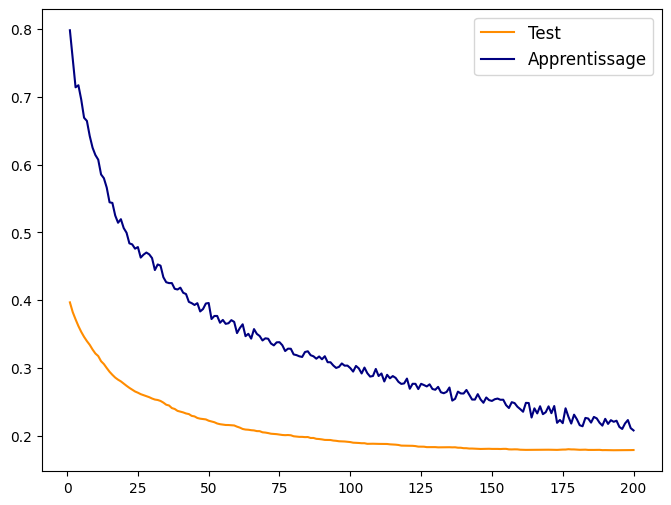

In [62]:
from sklearn.metrics import log_loss

niter = modelegbmCV.best_estimator_.n_estimators
iter = np.arange(niter) + 1
test_deviance = np.zeros((niter,), dtype=np.float64)

# staged_predict_proba donne les probabilités à chaque itération
for i, y_pred_proba in enumerate(modelegbmCV.best_estimator_.staged_predict_proba(X_test)):
    test_deviance[i] = log_loss(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(iter, test_deviance, label='Test', color='darkorange')
plt.plot(iter, modelegbmCV.best_estimator_.train_score_, label='Apprentissage', color='navy')
plt.legend(loc="upper right", fontsize=12)
plt.show()


In [63]:
# Algo avc les mêmes params sauf le nombre d'estimators que l'on met à 150 
# car nous remarquons qu'il n'y pas d'amélioration sur le test set après 150 itérations.
gbt_Rand = GradientBoostingClassifier(**modelegbmCV.best_params_)
gbt_Rand.n_estimators = 150
# Apprentissage du modele
gbt_Rand.fit(X_train,y_train)
gbt_Rand

,loss,'log_loss'
,learning_rate,0.05
,n_estimators,150
,subsample,0.9
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


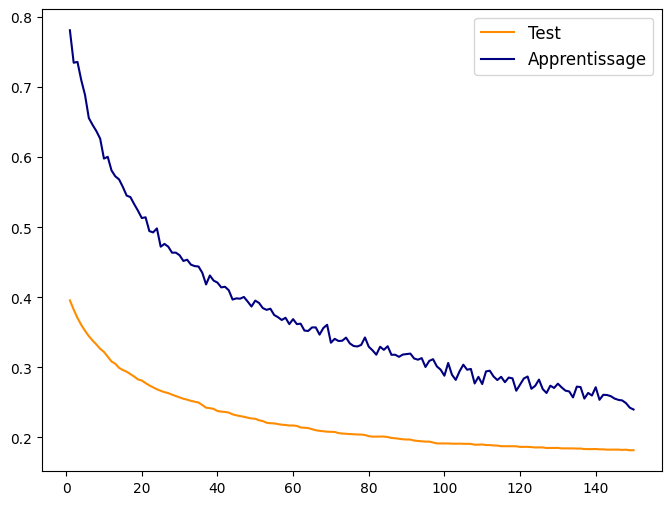

In [64]:
niter=gbt_Rand.n_estimators
iter = np.arange(niter) + 1
test_deviance = np.zeros((niter,), dtype=np.float64)
# staged_decision_functio : décision fonction à chaque iteration
for i, y_pred_proba in enumerate(gbt_Rand.staged_predict_proba(X_test)):
    test_deviance[i] = log_loss(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
# Erreur sur le test (evolution deviance)
plt.plot(iter,test_deviance,label='Test',color='darkorange')
        # min vers 100 
# Erreur sur apprentissage (evolution deviance)
plt.plot(iter,gbt_Rand.train_score_,label='Apprentissage',color='navy')    
# Diminution de l'erreur rapport modele precedant (par rapport au oob)
#plt.plot(iter,gbt_noRand05.oob_improvement_)
plt.legend(loc="upper right", fontsize=12)

### Analyser les résultats et les performances (meilleur modèle issue de la recherche d'hyperparamètres) 

In [65]:
# Prediction des probabilités de 1 , array2d
probas_test = modelegbmCV.predict_proba(X_test)[:,1]
probas_train = modelegbmCV.predict_proba(X_train)[:,1]


In [66]:
print(roc_auc_score(y_train,probas_train))
print(roc_auc_score(y_test,probas_test))


0.9811481366137237
0.9053438193184109


In [67]:
print(classification_report(y_train,modelegbmCV.predict(X_train), target_names=target_names))
print(classification_report(y_test,modelegbmCV.predict(X_test), target_names=target_names))

              precision    recall  f1-score   support

     Fidèles       0.97      1.00      0.99      1995
    Churners       0.99      0.84      0.91       338

    accuracy                           0.98      2333
   macro avg       0.98      0.92      0.95      2333
weighted avg       0.98      0.98      0.98      2333

              precision    recall  f1-score   support

     Fidèles       0.96      0.99      0.97       855
    Churners       0.92      0.73      0.82       145

    accuracy                           0.95      1000
   macro avg       0.94      0.86      0.89      1000
weighted avg       0.95      0.95      0.95      1000



In [68]:
# AJOUTE LES RESULTATS
model='best gbm from grid search'
# métriques (liste de dictionnaires)
metriques.append([{'model':model,'AUC_test':round(roc_auc_score(y_test,probas_test),3),'lift at 5':lift(probas_test,X_test,y_test,p=5),'lift at 10':lift(probas_test,X_test,y_test,p=10)}])
metriques
# conclusion  le modele RF est plus predictif mais moins confiance dans sa capacité à etre robuste à moyen terme


lift at 5 percent : 6.9
lift at 10 percent : 6.41


[{'model': 'Score Lasso',
  'AUC_test': 0.823,
  'lift at 5': np.float64(4.28),
  'lift at 10': np.float64(3.86)},
 [{'model': 'Score Random Forest',
   'AUC_test': 0.887,
   'lift at 5': np.float64(6.07),
   'lift at 10': np.float64(5.1)}],
 [{'model': 'best gbm from grid search',
   'AUC_test': 0.905,
   'lift at 5': np.float64(6.9),
   'lift at 10': np.float64(6.41)}]]

In [69]:
# Prediction des probabilités de 1 , array2d
probas_test = gbt_Rand.predict_proba(X_test)[:,1]
probas_train = gbt_Rand.predict_proba(X_train)[:,1]


In [70]:
print(roc_auc_score(y_train,probas_train))
print(roc_auc_score(y_test,probas_test))


0.9652822885616408
0.9050211736237145


In [71]:
print(classification_report(y_train,gbt_Rand.predict(X_train), target_names=target_names))
print(classification_report(y_test,gbt_Rand.predict(X_test), target_names=target_names))

              precision    recall  f1-score   support

     Fidèles       0.97      1.00      0.98      1995
    Churners       0.99      0.83      0.90       338

    accuracy                           0.97      2333
   macro avg       0.98      0.91      0.94      2333
weighted avg       0.97      0.97      0.97      2333

              precision    recall  f1-score   support

     Fidèles       0.95      0.99      0.97       855
    Churners       0.92      0.72      0.81       145

    accuracy                           0.95      1000
   macro avg       0.94      0.86      0.89      1000
weighted avg       0.95      0.95      0.95      1000

              precision    recall  f1-score   support

     Fidèles       0.95      0.99      0.97       855
    Churners       0.92      0.72      0.81       145

    accuracy                           0.95      1000
   macro avg       0.94      0.86      0.89      1000
weighted avg       0.95      0.95      0.95      1000



In [72]:
# AJOUTE LES RESULTATS
model='gbm light'
# métriques (liste de dictionnaires)
metriques.append([{'model':model,'AUC_test':round(roc_auc_score(y_test,probas_test),3),'lift at 5':lift(probas_test,X_test,y_test,p=5),'lift at 10':lift(probas_test,X_test,y_test,p=10)}])
metriques
# conclusion  le modele RF est plus predictif mais moins confiance dans sa capacité à etre robuste à moyen terme


lift at 5 percent : 6.76
lift at 10 percent : 6.48


[{'model': 'Score Lasso',
  'AUC_test': 0.823,
  'lift at 5': np.float64(4.28),
  'lift at 10': np.float64(3.86)},
 [{'model': 'Score Random Forest',
   'AUC_test': 0.887,
   'lift at 5': np.float64(6.07),
   'lift at 10': np.float64(5.1)}],
 [{'model': 'best gbm from grid search',
   'AUC_test': 0.905,
   'lift at 5': np.float64(6.9),
   'lift at 10': np.float64(6.41)}],
 [{'model': 'gbm light',
   'AUC_test': 0.905,
   'lift at 5': np.float64(6.76),
   'lift at 10': np.float64(6.48)}]]

# 4. Comparaison et conclusion 

In [73]:
metriques

[{'model': 'Score Lasso',
  'AUC_test': 0.823,
  'lift at 5': np.float64(4.28),
  'lift at 10': np.float64(3.86)},
 [{'model': 'Score Random Forest',
   'AUC_test': 0.887,
   'lift at 5': np.float64(6.07),
   'lift at 10': np.float64(5.1)}],
 [{'model': 'best gbm from grid search',
   'AUC_test': 0.905,
   'lift at 5': np.float64(6.9),
   'lift at 10': np.float64(6.41)}],
 [{'model': 'gbm light',
   'AUC_test': 0.905,
   'lift at 5': np.float64(6.76),
   'lift at 10': np.float64(6.48)}]]